In [18]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys

import main as lightcode
import hardware as hw
import graph_transformations as gt
import stacked_graph as sg
import input_validation as validate
import data_collection as dc
import code_generation as cg
import graph_visualization as gv
import models
import math

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:

# optimization = "time"
optimization = "energy"
# optimization = "always_phu"

CPU_MAX_CLOCK = 5.0875 * 10**9  # 5.0875 e+9 5Ghz
CPU_AVERAGE_CLOCK = 3.208 * 10**9  # 60**9, 6
PHU_MIN_CLOCK = 9.7 * 10**9  # 100**9, 10 Ghz

hardware = []
hw.Hardware._hardware_reset()
hardware.append(hw.CPU(CPU_AVERAGE_CLOCK, 1))
hardware.append(hw.PHU(PHU_MIN_CLOCK, 1, 20))

available_hardware = hw.initilize_hardware(hardware)
subgraph_idx  = 0

ans = lightcode.graph_search_debug(
    models.llama_prefill,
    optimization,
    available_hardware,
    moc_sequence_length = 3500,
    subgraph = subgraph_idx,
    profiles=True,
    data_collection=True,
)

subgraph = ans

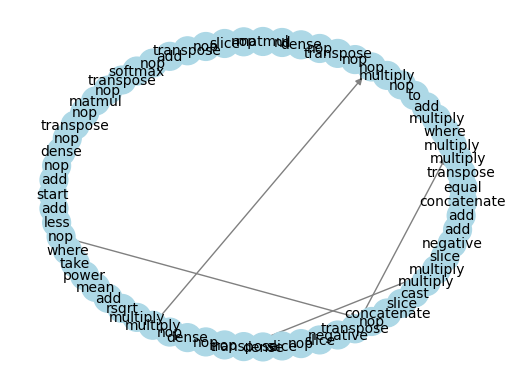

In [3]:
fig, ax = plt.subplots()

gv.adj_to_graph(
    subgraph,
    ax,
    save=False,
    layout="shell",
    title=f"Graph {subgraph_idx} with {len(subgraph)} nodes",
    stack=True,
)

plt.show()

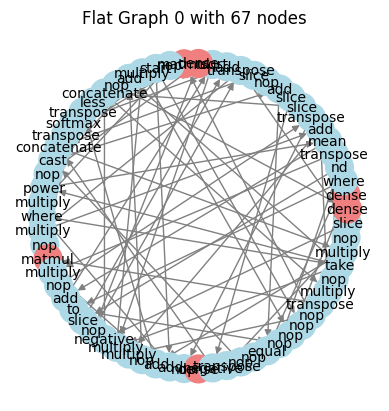

In [4]:
flat_subgraphs = gt.pathfinding_node_selection([subgraph], weight_variable=optimization)
flat_subgraph = flat_subgraphs[0]

fig, ax = plt.subplots()

gv.adj_to_graph(
    flat_subgraph,
    ax,
    save=False,
    layout="shell",
    title=f"Flat Graph {subgraph_idx} with {len(flat_subgraph)} nodes",
    stack=False,
)

plt.show()

In [5]:
print(len(flat_subgraph))
energy_data, delta_energy, total_energy = dc.get_energy_profile(flat_subgraph)
print(f'optimization {optimization:<12}: {total_energy} pj')

67
optimization energy      : 88149017655.3 pj


In [6]:
# for node in flat_subgraph:
    # if 'phu' in node.algorithm:
        # print(node)

In [7]:
expanded_flat_subgraphs = gt.expand_nodes(flat_subgraphs)
expanded_flat_subgraph = expanded_flat_subgraphs[0]

print(len(expanded_flat_subgraph))

energy_data, delta_energy, total_energy = dc.get_energy_profile(expanded_flat_subgraph)
print(f'optimization {optimization:<12} expanded: {total_energy} pj')

141
optimization energy       expanded: 87656432695.3 pj


In [16]:
# time_cost=7.65360824742268e-07
# subnodes_time_cost=8.445360824742268e-07

time_cost=2.6391752577319587e-08
subnodes_time_cost=4.222680412371134e-07


dif = abs(time_cost - subnodes_time_cost)
print(dif)

p_dif = dif/(max(time_cost, subnodes_time_cost))
print(p_dif)

3.9587628865979383e-07
0.9375


In [55]:
# Testing the effects of the ceil on the expansion step
def ten_elm(tensor_shape):
    """
    Args:
        tensor_shape (lsit or tuple)

    Returns:
        int: number of elements
    """
    ans = 1
    for dimention in tensor_shape:
        ans *= dimention
    return ans

def _phu_matmul_task_para_cycles(i, o):
    num_dot_products = ten_elm(o[0])
    print(f'{num_dot_products=}')
    print(f'{math.ceil(num_dot_products / 20)=}')
    length_dot_products = i[0][-1]
    phu_cycles = (
        math.ceil(math.ceil(num_dot_products / 20) / 1)
        * length_dot_products
    )
    return phu_cycles

l=2

i=[[32, l, 128], [32, l, 128]]
o=[[32, l, l]]
a=(_phu_matmul_task_para_cycles(i,o))
print(a)

i=[[l, 128], [l, 128]]
o=[[l, l]]
b=(_phu_matmul_task_para_cycles(i,o))
print(b*32)

print(abs(a-(b*32)))
print(max(a,b))
print(abs(a-(b*32))/max(a,(b*32)))


num_dot_products=128
math.ceil(num_dot_products / 20)=7
896
num_dot_products=4
math.ceil(num_dot_products / 20)=1
4096
3200
896
0.78125
